In [1]:
import cv2
from ultralytics import YOLO
from insightface.utils import face_align
import numpy as np
import matplotlib.pyplot as plt


DETECTION_MODEL_PATH = "/home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/models/Face&LandmarksDetector/YOLO26NANO_LRF#0.005&COS_LR#TRUE/best.pt"
model = YOLO(DETECTION_MODEL_PATH)
def get_face(image_path):
    def get_bbox_and_points(output):
        num_faces = len(output[0].boxes.conf)
        print(output[0].keypoints.conf.shape)
        print(num_faces)
        x, y, w, h = output[0].boxes.xywh[0]
        x = int(x-w/2)
        y = int(y-h/2)
        w = int(w)
        h = int(h)

        keypoints = output[0].keypoints.xy[0]
        kpx1, kpy1 = int(keypoints[0][0]), int(keypoints[0][1])
        kpx2, kpy2 = int(keypoints[1][0]), int(keypoints[1][1])
        kpx3, kpy3 = int(keypoints[2][0]), int(keypoints[2][1])
        kpx4, kpy4 = int(keypoints[3][0]), int(keypoints[3][1])
        kpx5, kpy5 = int(keypoints[4][0]), int(keypoints[4][1])

        return x, y, w, h, kpx1, kpy1, kpx2, kpy2, kpx3, kpy3, kpx4, kpy4, kpx5, kpy5


    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    output = model.predict(image_path)
    output[0].orig_img
    x, y, w, h, kpx1, kpy1, kpx2, kpy2, kpx3, kpy3, kpx4, kpy4, kpx5, kpy5 = get_bbox_and_points(output)
    landmarks = np.array([
        [kpx1, kpy1],
        [kpx2, kpy2],
        [kpx3, kpy3],
        [kpx4, kpy4],
        [kpx5, kpy5],
    ])


    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    aligned = face_align.norm_crop(image, landmark=landmarks, image_size=112)

    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 0, 225), 5)
    cv2.circle(image, center=(kpx1, kpy1), radius=5, thickness=5, color=(0, 125, 125))
    cv2.circle(image, center=(kpx2, kpy2), radius=5, thickness=5, color=(0, 125, 125))
    cv2.circle(image, center=(kpx3, kpy3), radius=5, thickness=5, color=(0, 125, 125))
    cv2.circle(image, center=(kpx4, kpy4), radius=5, thickness=5, color=(0, 125, 125))
    cv2.circle(image, center=(kpx5, kpy5), radius=5, thickness=5, color=(0, 125, 125))


    aligned = cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB)
    plt.imshow(aligned)
    plt.show()

    return aligned


image 1/1 /home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/2.jpeg: 640x640 1 person, 73.0ms
Speed: 2.1ms preprocess, 73.0ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([1, 5])
1


/home/mahmoud-sayed/miniconda3/envs/mainenv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


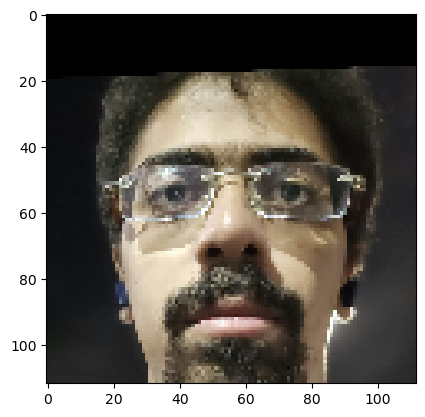


image 1/1 /home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/1.jpg: 640x640 6 persons, 44.8ms
Speed: 1.7ms preprocess, 44.8ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
torch.Size([6, 5])
6


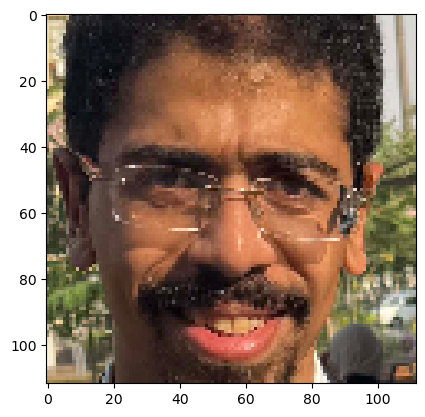


image 1/1 /home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/3.jpeg: 640x480 3 persons, 55.2ms
Speed: 3.4ms preprocess, 55.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)
torch.Size([3, 5])
3


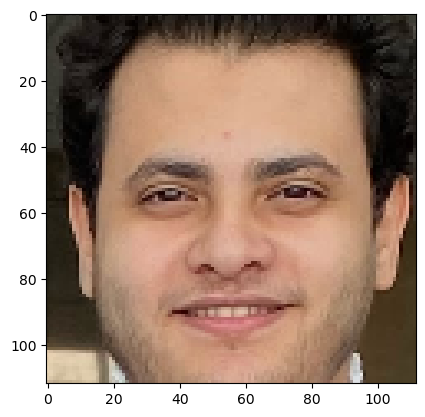

/home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/Embedding/models/iresnet.py:149: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):


NUMBER OF PARAMETRS:  24025600
NUMBER OF PARAMETRS:  24025600
NUMBER OF PARAMETRS:  24025600


In [2]:
import torch
from models import get_model
from embedding_model_test import embed
from models import get_model
IMAGE1_PATH = "/home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/2.jpeg"
IMAGE2_PATH = "/home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/1.jpg"
IMAGE3_PATH = "/home/mahmoud-sayed/Desktop/Code/Python/Computer Vision/Face Identification/input/3.jpeg"
face1 = get_face(IMAGE1_PATH)
face2 = get_face(IMAGE2_PATH)
face3 = get_face(IMAGE3_PATH)

EMBEDDING_WEIGHTS_PATH = "../models/FaceEmbedding/ms1mv3_arcface_r18_fp16.pth"

embeddings1 = embed("r18", EMBEDDING_WEIGHTS_PATH, False, face1)
embeddings2 = embed("r18", EMBEDDING_WEIGHTS_PATH, False, face2)
embeddings3 = embed("r18", EMBEDDING_WEIGHTS_PATH, False, face3)

In [3]:
embeddings1.dot(embeddings2)

np.float32(242.54434)

In [4]:
cos_sim = np.dot(embeddings1, embeddings2) / (np.linalg.norm(embeddings1) * np.linalg.norm(embeddings2))
print(cos_sim)
print((cos_sim+1)/2)

0.5379796
0.7689898


In [5]:
cos_sim = np.dot(embeddings1, embeddings3) / (np.linalg.norm(embeddings1) * np.linalg.norm(embeddings3))
print(cos_sim)
print((cos_sim+1)/2)

-0.058144137
0.47092792
